# Relative Value Difference Bias Check

This notebook will recover parameters from simulated data of three groups: large left preference, neutral perference, and large right preference. The underlying hypothesis is that parameter recovery bias (high noise, low drift) seems to be a result of a structural bias in the novel simulation methodology. Without quantifying this bias, which is believed to be conditional on relative value differences, the following work will only investigate the issues and determine if the bias is skewed towards large absolute value relative value differences if the bias is positionally dependent (left fixation is more likely).

## Stratifying Data

Define 
$$
\Delta_i = RDV_i = V_{L,i} - V_{R,i}.
$$

Then
$$
\mathcal{T}_R(\tau) = \{i:\Delta_i\le -\tau\},\\
\mathcal{T}_0(\epsilon) = \{i:|\Delta_i|\le\epsilon\},\\
\mathcal{T}_L(\tau) = \{i:\Delta_i\ge \tau\},
$$
and set $\tau = 3.5$ and $\epsilon = 0.5$.

In [1]:
# If the notebook is moved into /exploratory_notebooks, then uncomment the code below

# import sys, os

# sys.path.insert(0, os.path.abspath(".."))

In [2]:
import pandas as pd
from ast import literal_eval

df_raw = pd.read_csv('1ms_trial_data.csv')
df_raw['RT'] = df_raw['RT']*1000 # adjustment for RT
df_raw['fixation'] = df_raw['fixation'].apply(literal_eval)

to_drop = pd.read_csv("dropped_trials.csv").rename(columns={"parcode": "sub_id"})

df = df_raw.loc[
    ~df_raw.set_index(["sub_id", "trial"]).index.isin(
        to_drop.set_index(["sub_id", "trial"]).index
    )
    & (~df_raw["hidden"])
]


df.head()

,sub_id,trial,hidden,avgWTP_left,avgWTP_right,choice,RT,fixation
100,329,101,False,5.00,1.00,left,940.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
101,329,102,False,1.25,1.00,left,1147.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
102,329,103,False,5.00,1.00,left,818.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
103,329,104,False,1.25,4.25,right,796.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
104,329,105,False,4.00,3.75,right,1313.0,"(4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."


In [3]:
large_rvd_threshold = 3.5
neutral_rvd_threshold = 0.5

right_pref_df = df.loc[df["avgWTP_left"] - df["avgWTP_right"] <= -large_rvd_threshold]
neutral_pref_df = df.loc[abs(df["avgWTP_left"] - df["avgWTP_right"] <= 0.5)]
left_pref_df = df.loc[df["avgWTP_left"] - df["avgWTP_right"] >= large_rvd_threshold]

A quick reference to model-free analysis, the average response times of trials with large preferences to either stimuli should be shorter than trials with neutral perferences.

In [4]:
import numpy as np

print(f'Trials with large right preference: {right_pref_df.shape[0]} (average RT: {np.mean(right_pref_df['RT']):.2f} ms)')
print(f'Trials with neutral preference: {neutral_pref_df.shape[0]} (average RT: {np.mean(neutral_pref_df['RT']):.2f} ms)')
print(f'Trials with large left preference: {left_pref_df.shape[0]} (average RT: {np.mean(left_pref_df['RT']):.2f} ms)')

Trials with large right preference: 350 (average RT: 1033.77 ms)
Trials with neutral preference: 6183 (average RT: 1443.71 ms)
Trials with large left preference: 320 (average RT: 964.23 ms)


## Simulating Data

In [5]:
from simulation import get_corrected_empirical_distributions

legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, 
    "blank_fixation": {4}
}
fixation_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'
cutoff = 0.90

right_value_diffs = np.arange(-4, -3.25, 0.25)
right_empirical_distributions = get_corrected_empirical_distributions(
    right_pref_df,
    value_diffs=right_value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=cutoff
)

neutral_value_diffs = np.arange(-0.5, 0.75, 0.25)
neutral_empirical_distributions = get_corrected_empirical_distributions(
    neutral_pref_df,
    value_diffs=neutral_value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=cutoff
)

left_value_diffs = np.arange(3.5, 4.25, 0.25)
left_empirical_distributions = get_corrected_empirical_distributions(
    left_pref_df,
    value_diffs=left_value_diffs,
    legend=legend,
    fixation_col=fixation_col,
    left_value_col=left_value_col,
    right_value_col=right_value_col,
    cutoff=cutoff
)

In [6]:
print(f'Preference for first left choice in left preference: {left_empirical_distributions['probFixLeftFirst']}')
print(f'Preference for first left choice in neutral preference: {neutral_empirical_distributions['probFixLeftFirst']}')
print(f'Preference for first left choice in right preference: {right_empirical_distributions['probFixLeftFirst']}')

Preference for first left choice in left preference: 0.796875
Preference for first left choice in neutral preference: 0.7719269376337008
Preference for first left choice in right preference: 0.8411764705882353


In [7]:
right_trials = right_pref_df[['avgWTP_left', 'avgWTP_right']].sample(n=300, random_state=42)
right_trials['fixation'] = None

neutral_trials = neutral_pref_df[['avgWTP_left', 'avgWTP_right']].sample(n=300, random_state=42)
neutral_trials['fixation'] = None

left_trials = left_pref_df[['avgWTP_left', 'avgWTP_right']].sample(n=300, random_state=42)
left_trials['fixation'] = None

In [8]:
from simulation import generate_fixations

dt = 0.01

rng = np.random.default_rng(42)
right_trials_dict = []
for row in right_trials.itertuples(index=False):
    fx = generate_fixations(
        dt,
        row.avgWTP_left - row.avgWTP_right,
        right_empirical_distributions,
        rng=rng
    )
    if fx is not None:
        right_trials_dict.append({
            "avgWTP_left": row.avgWTP_left,
            "avgWTP_right": row.avgWTP_right,
            "fixation": fx
        })

rng = np.random.default_rng(42)
neutral_trials_dict = []
for row in neutral_trials.itertuples(index=False):
    fx = generate_fixations(
        dt,
        row.avgWTP_left - row.avgWTP_right,
        neutral_empirical_distributions,
        rng=rng
    )
    if fx is not None:
        neutral_trials_dict.append({
            "avgWTP_left": row.avgWTP_left,
            "avgWTP_right": row.avgWTP_right,
            "fixation": fx
        })

rng = np.random.default_rng(42)
left_trials_dict = []
for row in left_trials.itertuples(index=False):
    fx = generate_fixations(
        dt,
        row.avgWTP_left - row.avgWTP_right,
        left_empirical_distributions,
        rng=rng
    )
    if fx is not None:
        left_trials_dict.append({
            "avgWTP_left": row.avgWTP_left,
            "avgWTP_right": row.avgWTP_right,
            "fixation": fx
        })

In [26]:
from simulation import simulate

seed = 42
model_conditions = {'drift_rate': 0.2, 'theta': 0.5, 'noise': 0.93}

right_results_df = simulate(dt, model_conditions, right_trials_dict, seed=seed, save_results=False)
right_results_df['sub_id'] = f'seed{seed}_preferenceR_sim'
right_results_df['trial'] = range(1, len(right_trials_dict) + 1)
right_results_df = right_results_df.rename(columns={'fixation': 'fix_sequence'})
# right_results_df = right_results_df.drop(columns = ['trajectory'])
print(f'Average RT: {np.average(right_results_df.loc[:, "RT"]):.3f} seconds')
right_results_df.head()

Average RT: 1.122 seconds


,trajectory,avgWTP_left,avgWTP_right,fix_sequence,RT,choice,sub_id,trial
0,"[8.881784197001252e-16, 0.12643218713942453, 0...",1.0,5.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.56,1,seed42_preferenceR_sim,1
1,"[8.881784197001252e-16, 0.052928332521344164, ...",1.5,5.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, ...",0.97,1,seed42_preferenceR_sim,2
2,"[8.881784197001252e-16, -0.10089777293701209, ...",1.0,5.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.21,0,seed42_preferenceR_sim,3
3,"[8.881784197001252e-16, -0.1547365642856369, -...",1.0,5.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.17,1,seed42_preferenceR_sim,4
4,"[8.881784197001252e-16, -0.014943349683199008,...",1.0,4.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",0.29,0,seed42_preferenceR_sim,5


In [27]:
neutral_results_df = simulate(dt, model_conditions, neutral_trials_dict, seed=seed, save_results=False)
neutral_results_df['sub_id'] = f'seed{seed}_preferenceN_sim'
neutral_results_df['trial'] = range(1, len(neutral_trials_dict) + 1)
neutral_results_df = neutral_results_df.rename(columns={'fixation': 'fix_sequence'})
# neutral_results_df = neutral_results_df.drop(columns = ['trajectory'])
print(f'Average RT: {np.average(neutral_results_df.loc[:, "RT"]):.3f} seconds')
neutral_results_df.head()

Average RT: 1.195 seconds


,trajectory,avgWTP_left,avgWTP_right,fix_sequence,RT,choice,sub_id,trial
0,"[8.881784197001252e-16, 0.12643218713942453, 0...",1.00,5.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.97,1,seed42_preferenceN_sim,1
1,"[8.881784197001252e-16, 0.052928332521344164, ...",4.00,4.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3.20,1,seed42_preferenceN_sim,2
2,"[8.881784197001252e-16, -0.10089777293701209, ...",3.00,5.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.21,0,seed42_preferenceN_sim,3
3,"[8.881784197001252e-16, -0.1547365642856369, -...",1.75,2.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",1.32,1,seed42_preferenceN_sim,4
4,"[8.881784197001252e-16, -0.014943349683199008,...",4.50,4.75,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.29,0,seed42_preferenceN_sim,5


In [28]:
left_results_df = simulate(dt, model_conditions, left_trials_dict, seed=seed, save_results=False)
left_results_df['sub_id'] = f'seed{seed}_preferenceL_sim'
left_results_df['trial'] = range(1, len(left_trials_dict) + 1)
left_results_df = left_results_df.rename(columns={'fixation': 'fix_sequence'})
# left_results_df = left_results_df.drop(columns = ['trajectory'])
print(f'Average RT: {np.average(left_results_df.loc[:, "RT"]):.3f} seconds')
left_results_df.head()

Average RT: 1.260 seconds


,trajectory,avgWTP_left,avgWTP_right,fix_sequence,RT,choice,sub_id,trial
0,"[8.881784197001252e-16, 0.12643218713942453, 0...",4.75,1.25,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.39,0,seed42_preferenceL_sim,1
1,"[8.881784197001252e-16, 0.052928332521344164, ...",4.75,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.70,0,seed42_preferenceL_sim,2
2,"[8.881784197001252e-16, -0.10089777293701209, ...",4.75,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.21,0,seed42_preferenceL_sim,3
3,"[8.881784197001252e-16, -0.1547365642856369, -...",5.00,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.85,0,seed42_preferenceL_sim,4
4,"[8.881784197001252e-16, -0.014943349683199008,...",5.00,1.00,"(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.26,0,seed42_preferenceL_sim,5


In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from simulation import create_model

mpl.rcParams.update({
    "svg.fonttype": "none",   # keep text as text
    "font.size": 22,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

# Pale OPAQUE tints (no alpha needed)
LEFT_SHADE  = "#d9eaf7"  # light blue
RIGHT_SHADE = "#f9d7d7"  # light red

def plot_trajectory(dt, trial, model_conditions, save_path=None):
    """
    Plots the trajectory of the decision variable over time,
    shading periods of fixation left/right.

    Parameters:
    - trial: dict with keys:
        - 'trajectory': list or np.array of decision variable
        - 'fixation': list or np.array of fixation states (1=left, 2=right)
    - model_conditions: dict with keys 'drift_rate', 'theta', 'noise'
    - save_path: optional SVG path
    """
    # NOTE: assuming you have simulation.create_model in scope
    model = create_model( 
        model_conditions['drift_rate'],
        model_conditions['theta'],
        model_conditions['noise'],
        dt
    )

    trajectory = np.array(trial['trajectory'])
    fixation   = np.array(trial['fix_sequence'])
    timesteps  = np.arange(len(trajectory)) * model.dt

    # --- Figure / axes with WHITE background to avoid darkening via transparency compositing ---
    fig, ax = plt.subplots(figsize=(15, 10))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Trajectory on top
    ax.plot(timesteps, trajectory, color="black", linewidth=2.0, label="Trajectory", zorder=3)

    # Identify contiguous fixation segments
    current_state = fixation[0]
    start_idx = 0
    for i in range(1, len(fixation)):
        is_state_change = fixation[i] != current_state
        is_last_point   = (i == len(fixation) - 1)
        if is_state_change or is_last_point:
            # include the last index in the span if we are at the very end
            end_idx = i if is_state_change else i + 1
            x0, x1 = timesteps[start_idx], timesteps[end_idx - 1]

            if current_state == 1:
                # OPAQUE pale fill, no edge, behind the line
                ax.axvspan(x0, x1, color=LEFT_SHADE, ec="none", zorder=1,
                           label="Fixation Left" if start_idx == 0 else None)
            elif current_state == 2:
                ax.axvspan(x0, x1, color=RIGHT_SHADE, ec="none", zorder=1,
                           label="Fixation Right" if start_idx == 0 else None)

            start_idx = i
            current_state = fixation[i]

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Decision Variable")
    ax.set_title("aDDM Accumulation Trajectory with Fixation Shading")
    ax.grid(True, zorder=0)

    # De-duplicate legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    # Drop any None keys that can sneak in when label=None above
    by_label = {k: v for k, v in by_label.items() if k is not None}
    ax.legend(by_label.values(), by_label.keys(), frameon=False)

    plt.tight_layout()

    if save_path:
        # transparent=False ensures white background is embedded in the SVG
        plt.savefig(save_path, format="svg", dpi=300, bbox_inches="tight", transparent=False)

    plt.show()

Trial 1


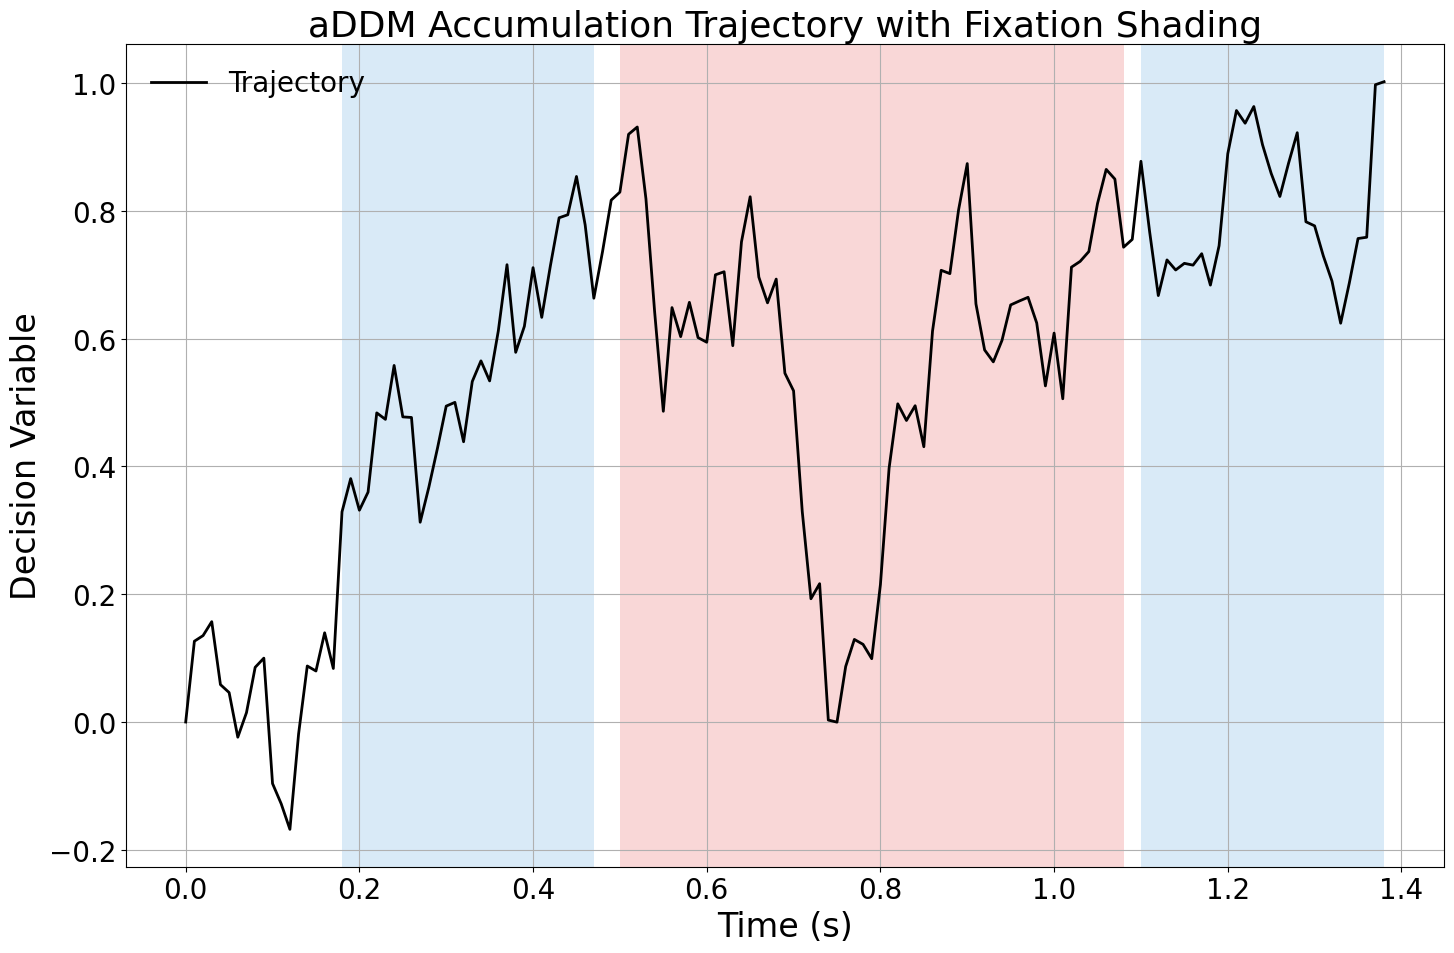

Trial 2


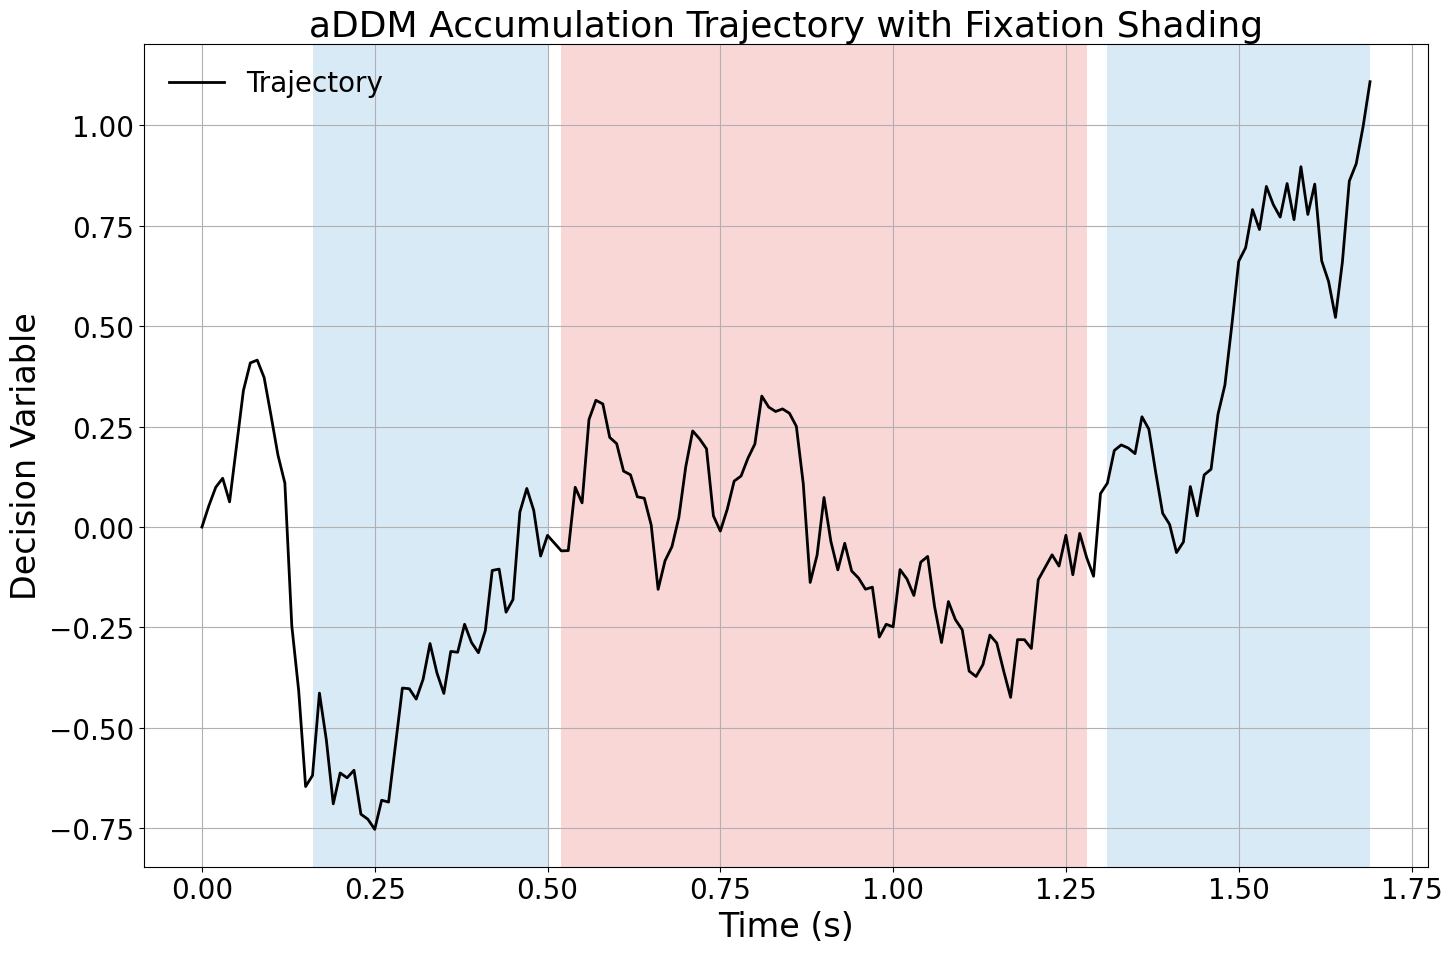

In [30]:
for i in range(2):
    print(f'Trial {left_results_df.iloc[i]["trial"]}')
    plot_trajectory(dt, left_results_df.iloc[i], model_conditions)